In [1]:
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Machine Learning Model
from sklearn.linear_model import LinearRegression

# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\medical_insurance_dataset.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,58,male,17.1,2,no,northeast,15441.0
1,61,male,30.4,0,yes,northeast,37073.0
2,50,male,29.7,5,no,southwest,19089.0
3,46,female,35.5,0,no,northeast,19052.0
4,39,female,20.2,2,yes,southwest,30656.0


In [4]:
df.shape

(200, 7)

In [5]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       200 non-null    int64  
 1   sex       200 non-null    object 
 2   bmi       200 non-null    float64
 3   children  200 non-null    int64  
 4   smoker    200 non-null    object 
 5   region    200 non-null    object 
 6   charges   200 non-null    float64
dtypes: float64(2), int64(2), object(3)
memory usage: 11.1+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,200.000000,200.000000,200.000000,200.000000
mean,40.600000,28.223500,2.600000,20664.770000
std,13.606827,6.749547,1.704266,8312.098825
min,18.000000,16.500000,0.000000,9058.000000
25%,28.000000,22.625000,1.000000,15016.500000
50%,41.000000,28.250000,3.000000,18103.000000
75%,52.000000,34.200000,4.000000,21921.250000
max,64.000000,39.700000,5.000000,42819.000000


In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
# Create LabelEncoder object
le = LabelEncoder()

# Encode categorical columns
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

In [10]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,58,1,17.1,2,0,0,15441.0
1,61,1,30.4,0,1,0,37073.0
2,50,1,29.7,5,0,3,19089.0
3,46,0,35.5,0,0,0,19052.0
4,39,0,20.2,2,1,3,30656.0


In [11]:
# Separate features and target
X = df.drop('charges', axis=1)
y = df['charges']

# Apply Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display the first 5 scaled rows
pd.DataFrame(X_scaled, columns=X.columns).head()

,age,sex,bmi,children,smoker,region
0,1.281979,1.010051,-1.652172,-0.352941,-0.515580,-1.294715
1,1.503010,1.010051,0.323275,-1.529412,1.939563,-1.294715
2,0.692563,1.010051,0.219304,1.411765,-0.515580,1.347560
3,0.397856,-0.990050,1.080778,-1.529412,-0.515580,-1.294715
4,-0.117883,-0.990050,-1.191730,-0.352941,1.939563,1.347560


In [12]:
# Split dataset into training and testing sets (80% training, 20% testing)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)

Training Features Shape : (160, 6)
Testing Features Shape  : (40, 6)
Training Target Shape   : (160,)
Testing Target Shape    : (40,)


In [13]:
# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [14]:
# Display model coefficients and intercept

print("Intercept:", model.intercept_)

print("\nCoefficients:")

for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")

Intercept: 20700.71911859203

Coefficients:
age: 2254.3204
sex: -59.8980
bmi: 1784.6354
children: 566.8192
smoker: 7528.0920
region: -101.1835


In [15]:
# Predict on the test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display the results
print("Model Evaluation Metrics")
print("-" * 30)
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

Model Evaluation Metrics
------------------------------
Mean Absolute Error (MAE): 1297.92
Mean Squared Error (MSE): 2132308.27
Root Mean Squared Error (RMSE): 1460.24
R² Score: 0.9688


In [16]:
# Training Performance
train_pred = model.predict(X_train)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, y_pred)

print("Training R² Score :", round(train_r2, 4))
print("Testing R² Score  :", round(test_r2, 4))

Training R² Score : 0.9767
Testing R² Score  : 0.9688


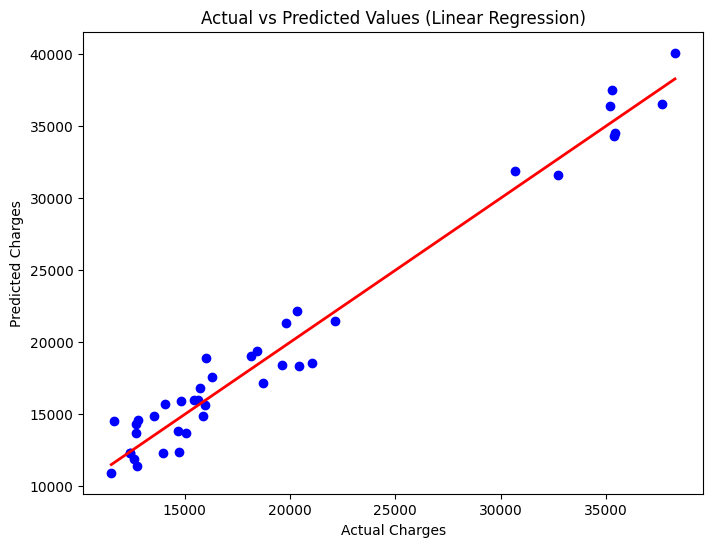

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, color='blue')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Values (Linear Regression)")

plt.show()